In [ ]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import random
import math

random.seed(19)
batch_size = 8
learning_rate = 0.01

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0 
X_test = X_test / 255.0


print("X_train data shape:", X_train.shape)
print("Y_train data shape:", y_train.shape)
print("X_test data shape:", X_test.shape)
print("y_test data shape:", y_test.shape)


X_train data shape: (60000, 28, 28)
Y_train data shape: (60000,)
X_test data shape: (10000, 28, 28)
y_test data shape: (10000,)


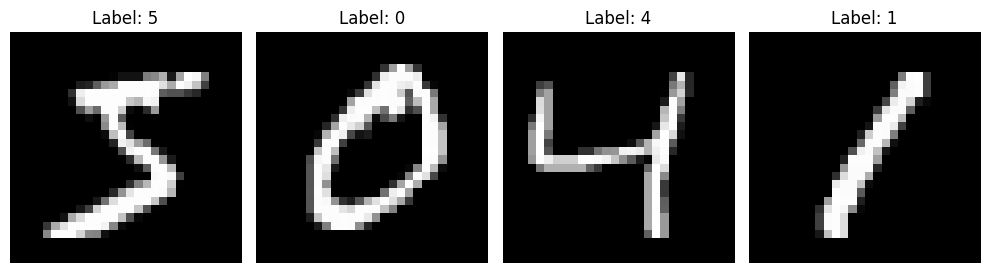

In [4]:
plt.figure(figsize=(10, 3))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
layer1 = [] # list of length 28*28=784 neurons

weights_layer12 = [[random.randint(-99,99)/100 for _ in range(X_train.shape[1]*X_train.shape[2])] for _ in range(16)] #matric of 16 rows and 784 columns
biases_layer2 = [random.randint(-99,99)/100 for _ in range (16)]

layer2 = [0 for _ in range(0,16)] #list of length 16 neurons

weights_layer23 = [[random.randint(-99,99)/100 for _ in range(16)] for _ in range(10)] #matrix of 10 rows and 16 columns
biases_layer3 = [random.randint(-99,99)/100 for _ in range (10)]

layer3=[] #list of length 10 neurons


In [25]:
#training code
for batch in range(0,len(X_train),batch_size):
    print(batch)
    labels=[label for label in y_train[batch:batch+batch_size]]

    for image in range(0,batch_size):

        layer1 = X_train[batch+image].flatten().tolist()

        layer2 = []
        for layer2_neuron in range(0,16):
            z_func = sum([a[0]*a[1] for a in zip(weights_layer12[layer2_neuron],layer1)]) + biases_layer2[layer2_neuron]
            layer2.append(z_func)
            #print(type(layer2[0]))

        layer3 = []
        for layer3_neuron in range(0,10):
            z_func = sum([b[0]*max(b[1],0) for b in zip(weights_layer23[layer3_neuron],layer2)]) + biases_layer3[layer3_neuron]
            layer3.append(z_func)
        
        logits = [round(math.exp(logit),3) for logit in layer3]
        sumexp = sum(logits)
        probs = [prob/sumexp for prob in logits]
        loss = -1 * math.log(probs[labels[image]])
        print(loss)
        
        probs[labels[image]]-=1
        layer3_error = probs #list of 10 errors

        layer3_grad = []
        for gradient_index in range(0,len(layer3_error)):
            layer3_neuron_grad = []
            for z in layer2: 
                layer3_neuron_grad.append(max(z,0) * layer3_error[gradient_index])
            layer3_grad.append(layer3_neuron_grad)

        layer3_grad = layer3_grad # gradients for layer 3 weights, matrix of 10 rows and 16 columns

        #layer2_error = layer3_error * weights_layer23
        layer2_error = []

        for column in range(len(weights_layer23[0])):
            error_sum = 0
            for row in range(len(layer3_error)):
                error_sum +=weights_layer23[row][column]*layer3_error[row]
            layer2_error.append(error_sum)
        
        layer2_error = layer2_error #list of 16 errors
        
        for z in range(len(layer2)):
            if layer2[z]<0:
                layer2_error[z]=0
        
        layer2_grad=[]
        for gradient_index in range(0,len(layer2_error)):
            layer2_neuron_grad = []
            for z in layer1: 
                layer2_neuron_grad.append(z * layer2_error[gradient_index])
            layer2_grad.append(layer2_neuron_grad)
        
        layer2_grad = layer2_grad # gradient for layer2 weights, matrix of 16 rows and 784 columns

        for row in range(len(weights_layer23)):
            for column in range(len(weights_layer23[row])):
                weights_layer23[row][column] -= learning_rate * layer3_grad[row][column]
        
        for row in range(len(weights_layer12)):
            for column in range(len(weights_layer12[row])):
                weights_layer12[row][column] -= learning_rate * layer2_grad[row][column]
        
        for bias_index in range(len(layer3_error)):
            biases_layer3[bias_index] -= learning_rate * layer3_error[bias_index]

        for bias_index in range(len(layer2_error)):
            biases_layer2[bias_index] -= learning_rate * layer2_error[bias_index]

0


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
#inference code


True
